## Investigation on free boundary

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes.tree.tree import BinomialTree
from utility.simulate import simulate_gbm

from config.plot_settings import *

In [2]:
S0 = 1.0
K = 1.0
T = 1.0
r = 0.1
sigma = 0.5

bt = BinomialTree(K, r, sigma, T, n_steps=100)

In [3]:
ts = np.linspace(0, T, 101)
free_boundary = np.zeros(101)

for i in range(100):
    t = ts[i]
    # Find smallest S such that option value is greater than intrinsic value by binary search
    low = 0.0
    high = 2.0 * S0
    while high - low > 1e-5:
        mid = (low + high) / 2
        option_value = bt.predict(t, mid)
        intrinsic_value = max(0.0, K - mid)
        if option_value > intrinsic_value:
            high = mid
        else:
            low = mid
    free_boundary[i] = (low + high) / 2

free_boundary[-1] = K

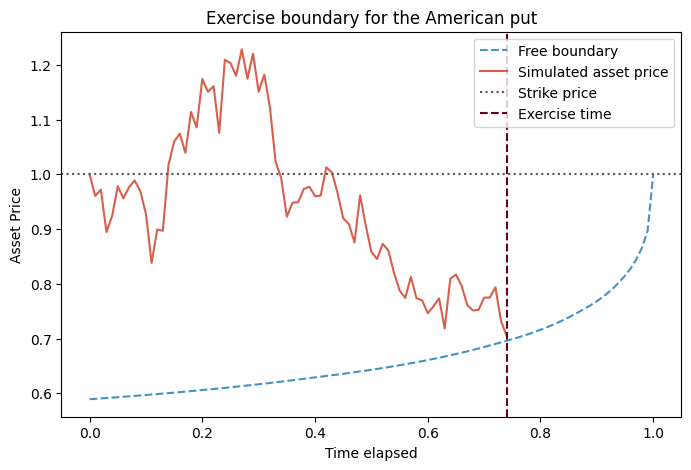

In [4]:
S_simulated = simulate_gbm(S0, r, sigma, T, N=100, n_paths=1, seed=9).flatten()

exercise_ind = np.where(S_simulated < free_boundary)[0][0]

plt.figure(figsize=figsize1)
plt.plot(ts, free_boundary, linestyle='--', label='Free boundary')
plt.plot(ts[:exercise_ind], S_simulated[:exercise_ind], linestyle='-', label='Simulated asset price')

plt.axhline(K, color=GRAPHITE, linestyle=':', label='Strike price')
plt.axvline(ts[exercise_ind - 1], color=CRIMSON, linestyle='--', label="Exercise time")

plt.title("Exercise boundary for the American put")
plt.xlabel('Time elapsed')
plt.ylabel('Asset Price')
plt.legend()
plt.savefig("../../plots/mathematical_background/free_boundary.png")
plt.show()
